# 09 - Task 3: Locating the optimum, and re-testing every model at matched share

Round 1 (notebook 08) confirmed the class-balance hypothesis and produced a new best
score. This notebook follows up on the two things it left open.

## What round 1 established

| submission | share | Kaggle | role |
|---|---|---|---|
| elasticnet @ 0.650 | 0.4996 | **0.71691** | new best, +0.021 over the old best |
| elasticnet @ 0.550 | 0.6081 | 0.71300 | |
| elasticnet @ 0.500 | 0.6608 | 0.69576 | previous best |
| ensemble @ 0.5617 | 0.6608 | 0.69476 | control B |
| linearsvc @ 0.500 | 0.6630 | 0.69013 | control A |

**1. Class balance is a first-order effect; model identity is second-order.** Control B
is the decisive one: the ensemble and ElasticNet were submitted at *identical* 0.6608
share and scored 0.69476 vs 0.69576, a gap of 0.001. The ensemble's +0.0017 local CV
advantage did not transfer at all. Control A puts LinearSVC 0.0056 behind ElasticNet at
near-identical share. So swapping models moves the score by ~0.005, while moving class
balance moves it by 0.021 or more. **The ensemble is abandoned** - it costs a member's
worth of complexity for no measurable gain.

**2. The curve is flattening, and the peak is suspiciously close to 0.50.** Marginal
slope along the ElasticNet-only curve (model held constant, threshold the only variable):

| share range | dF1 | slope |
|---|---|---|
| 0.7000 -> 0.6608 | +0.01999 | -0.510 |
| 0.6608 -> 0.6081 | +0.01724 | -0.327 |
| 0.6081 -> 0.4996 | +0.00391 | -0.036 |

The slope has collapsed by a factor of 14, so the optimum is at or just below 0.4996.

## The hypothesis this notebook tests

**The test set may simply be class-balanced 50/50 by design**, against train's 62.52/37.48.
Macro F1 is maximized when predicted balance matches true balance, and the best score so
far sits at share 0.4996, which is 0.50 to within one row in 6,999. That would be a
natural way for the organizers to build an evaluation set, and it would explain the
entire train-to-test shift the brief warns about with one number rather than with vague
appeals to "different sampling".

If true, two things follow, and both are testable here:

- Pushing share below ~0.50 should now *hurt*. Sections 3-4 place points at 0.45 and
  0.40 to find the far side of the peak.
- **Every model should peak near 0.50, including LightGBM.** LightGBM has the best local
  CV of anything tried (0.7443, ahead of ElasticNet's 0.7290) but the worst Kaggle score
  (0.65738) - and it was submitted at share 0.7495, by far the most miscalibrated of any
  submission. If balance explains the ordering, LightGBM re-submitted at share 0.4996
  should not merely improve, it should plausibly **beat ElasticNet**, because it was
  never actually the weaker model - it was the worse-calibrated one.

That last prediction is the most consequential thing left to test in this project, and
it is falsifiable: if LightGBM at matched share still trails ElasticNet at matched share,
then boosting genuinely transports worse and the local-vs-Kaggle inversion is not purely
a calibration artifact.

## 0. Setup

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from src import paths, data
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. The curve so far

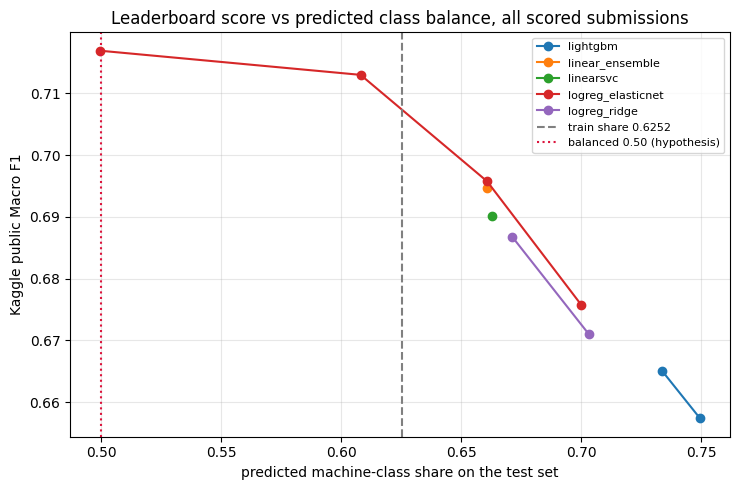

In [2]:
SCORED = pd.DataFrame([
    ("lightgbm", 0.7495, 0.65738), ("lightgbm", 0.7338, 0.66502),
    ("logreg_ridge", 0.7031, 0.67105), ("logreg_elasticnet", 0.7000, 0.67577),
    ("logreg_ridge", 0.6712, 0.68681), ("linearsvc", 0.6630, 0.69013),
    ("linear_ensemble", 0.6608, 0.69476), ("logreg_elasticnet", 0.6608, 0.69576),
    ("logreg_elasticnet", 0.6081, 0.71300), ("logreg_elasticnet", 0.4996, 0.71691),
], columns=["model", "share", "kaggle_f1"])

fig, ax = plt.subplots(figsize=(7.5, 5))
for model, sub in SCORED.groupby("model"):
    sub = sub.sort_values("share")
    ax.plot(sub["share"], sub["kaggle_f1"], marker="o", label=model)
ax.axvline(0.6252, color="grey", linestyle="--", label="train share 0.6252")
ax.axvline(0.50, color="crimson", linestyle=":", label="balanced 0.50 (hypothesis)")
ax.set_xlabel("predicted machine-class share on the test set")
ax.set_ylabel("Kaggle public Macro F1")
ax.set_title("Leaderboard score vs predicted class balance, all scored submissions")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "class_balance_curve_round1.png", dpi=120)
plt.show()

## 2. Share-matching helper

Rather than picking a probability threshold and seeing what share falls out, this takes
the *share* as the target and solves for the threshold via the empirical quantile of the
predicted probabilities. That makes different models directly comparable: two models set
to the same share differ only in *which* rows they call machine, never in how many.

This is the whole point. It converts "which model is best?" from a question confounded by
calibration into a clean one.

In [3]:
X, y, ids = data.load_train_features()
Xt, test_ids = data.load_test_features()

sample = pd.read_csv(paths.DATA_RAW / "sample_submission.csv", dtype={"id": str})
assert len(test_ids) == 6999, len(test_ids)
assert list(test_ids) == list(sample["id"]), "test ids do not match sample_submission order"


def test_proba(model_file):
    """Machine-class probability on the test set from a persisted full-refit model."""
    est = joblib.load(paths.MODELS / model_file)
    return est.predict_proba(Xt)[:, 1]


def write_at_share(proba, target_share, filename):
    """Threshold `proba` so exactly `target_share` of rows are predicted machine.

    Parameters
    ----------
    proba : ndarray, shape (n_test,)
    target_share : float
    filename : str

    Returns
    -------
    dict
    """
    thr = float(np.quantile(proba, 1 - target_share))
    preds = (proba >= thr).astype(int)
    data.write_submission(test_ids, preds, filename)
    return {"file": filename, "target_share": target_share,
            "actual_share": round(float(preds.mean()), 4), "threshold": round(thr, 4)}


# LinearSVC is added in the next cell - it has no predict_proba and needs the
# decision_function fallback.
proba = {
    "logreg_elasticnet": test_proba("final_logreg_elasticnet_full_refit.pkl"),
    "lightgbm": test_proba("final_lightgbm_full_refit.pkl"),
}
for name, p in proba.items():
    print(f"{name:20s} natural share @ 0.5: {(p >= 0.5).mean():.4f}")

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


logreg_elasticnet    natural share @ 0.5: 0.6608
lightgbm             natural share @ 0.5: 0.7495


### A note on LinearSVC's probabilities

`final_linearsvc_full_refit.pkl` is a bare `LinearSVC`, which has no `predict_proba`.
Share-matching only needs a monotonic *ranking* of rows, not calibrated probabilities,
so `decision_function` serves identically here - the quantile cut lands on the same rows
either way. The cell below handles that case explicitly rather than silently.

In [4]:
est = joblib.load(paths.MODELS / "final_linearsvc_full_refit.pkl")
if hasattr(est, "predict_proba"):
    proba["linearsvc"] = est.predict_proba(Xt)[:, 1]
else:
    # Monotonic in the same order as any calibrated probability would be.
    proba["linearsvc"] = est.decision_function(Xt)
    print("LinearSVC: using decision_function as the ranking score")
print(f"linearsvc score range: {proba['linearsvc'].min():.3f} .. {proba['linearsvc'].max():.3f}")

LinearSVC: using decision_function as the ranking score
linearsvc score range: -1.923 .. 1.897


## 3. Round-2 batch

Five uploads, split between locating the peak and re-testing models at the peak.

**Peak location (ElasticNet, model held constant).** Points at share 0.55, 0.45 and 0.40.
With the existing 0.6081 and 0.4996 results this gives a five-point curve across
0.40-0.61, which brackets the optimum on both sides instead of leaving it open-ended at
the low end.

**Model re-test at matched share 0.4996.** LightGBM and LinearSVC, both set to the exact
share of the current best submission. Since ElasticNet at that share scored 0.71691, any
difference is attributable purely to which rows each model ranks as machine.

In [5]:
BEST_SHARE = 0.4996  # elasticnet @ 0.650, Kaggle 0.71691

batch = []
# Peak location, ElasticNet only.
for s in [0.55, 0.45, 0.40]:
    batch.append({**write_at_share(proba["logreg_elasticnet"], s,
                                   f"elasticnet_share{int(s * 100)}.csv"),
                  "model": "logreg_elasticnet", "role": "peak location"})

# Model re-test at the current best share.
for m in ["lightgbm", "linearsvc"]:
    batch.append({**write_at_share(proba[m], BEST_SHARE, f"{m}_share50.csv"),
                  "model": m, "role": "model re-test at matched share"})

batch = pd.DataFrame(batch)[["file", "model", "role", "target_share", "actual_share", "threshold"]]
print(batch.to_string(index=False))

                  file             model                           role  target_share  actual_share  threshold
elasticnet_share55.csv logreg_elasticnet                  peak location        0.5500        0.5499     0.6067
elasticnet_share45.csv logreg_elasticnet                  peak location        0.4500        0.4501     0.6940
elasticnet_share40.csv logreg_elasticnet                  peak location        0.4000        0.4001     0.7357
  lightgbm_share50.csv          lightgbm model re-test at matched share        0.4996        0.4996     0.8186
 linearsvc_share50.csv         linearsvc model re-test at matched share        0.4996        0.4996     0.2024


In [6]:
# How much do the matched-share models actually differ from the current best submission?
# If two models disagree on very few rows, the comparison is low-powered and a small
# score difference should not be over-interpreted.
bench = pd.read_csv(paths.SUBMISSIONS / "logreg_elasticnet_thr65.csv")["label"].to_numpy()
print(f"Benchmark: logreg_elasticnet_thr65.csv, share {bench.mean():.4f}, Kaggle 0.71691\n")
for m in ["lightgbm", "linearsvc"]:
    other = pd.read_csv(paths.SUBMISSIONS / f"{m}_share50.csv")["label"].to_numpy()
    n_diff = int((other != bench).sum())
    print(f"{m:12s} differs from benchmark on {n_diff:5d} / {len(bench)} rows "
          f"({n_diff / len(bench):.1%})")

Benchmark: logreg_elasticnet_thr65.csv, share 0.4996, Kaggle 0.71691

lightgbm     differs from benchmark on   956 / 6999 rows (13.7%)
linearsvc    differs from benchmark on   334 / 6999 rows (4.8%)


## 4. How to read the results

**Peak location (shares 0.55, 0.45, 0.40 against the known 0.4996 -> 0.71691):**

- 0.45 and 0.40 both score below 0.71691 -> the optimum is at or just above 0.4996, which
  is consistent with a balanced 50/50 test set and closes the question. Ship the best
  point.
- 0.45 or 0.40 scores *above* 0.71691 -> the true test share is lower than 0.50 and the
  balanced-test-set story is wrong. Keep descending in a round 3.
- 0.55 beats 0.4996 -> the peak sits between 0.50 and 0.61 and the flattening seen in
  round 1 was noise rather than an approach to the optimum.

**Model re-test at matched share 0.4996 (vs ElasticNet's 0.71691):**

- LightGBM beats it -> its local CV lead was real all along and its earlier last-place
  finish was entirely a calibration artifact. This would be the headline finding of the
  project: the local-vs-leaderboard inversion would be fully explained by class balance,
  with no genuine difference in how model families transport.
- LightGBM roughly ties it -> balance explains most of the inversion but boosting has no
  real edge here either.
- LightGBM still trails clearly -> boosting genuinely transports worse across the shift,
  the linear-family preference established earlier was correct on its own merits, and
  calibration is only part of the story.

## 5. The risk that has to stay on the record

Every number here comes from the **public** leaderboard, which covers only ~51% of the
test rows, while the grade comes from the **private** one. There is a specific reason for
concern beyond ordinary overfitting: the `id` formats suggest the 6,999 test rows are
1,999 UUID-style rows (sharing train's id provenance) plus 5,000 numeric-style rows, and
if public and private are split along that line, the two halves may not share the same
true class balance. A share tuned to one could be wrong for the other.

Three points argue for proceeding anyway. The effect is large (0.021 F1 from one
threshold change, versus ~0.005 from swapping the entire model). It is a single
parameter, not added model complexity, so it is not over-engineering in the sense the
brief warns about. And the direction is supported by ten submissions with a perfectly
monotonic relationship, not by a single lucky result.

But the honest position for the Task 4 report is that this is a calibrated bet on the
public leaderboard being representative, not a certainty - and if the private score comes
in well below the public one, this is the first place to look.

In [7]:
ledger_path = paths.DATA_PROCESSED / "calibration_results_round2.csv"
batch["kaggle_f1"] = np.nan
if ledger_path.exists():
    prev = pd.read_csv(ledger_path)[["file", "kaggle_f1"]].dropna()
    if len(prev):
        batch = batch.drop(columns="kaggle_f1").merge(prev, on="file", how="left")
batch.to_csv(ledger_path, index=False)
print(batch.to_string(index=False))
print(f"\nBenchmark to beat: 0.71691 (elasticnet, share 0.4996)")
print(f"Ledger: {ledger_path}")

                  file             model                           role  target_share  actual_share  threshold  kaggle_f1
elasticnet_share55.csv logreg_elasticnet                  peak location        0.5500        0.5499     0.6067        NaN
elasticnet_share45.csv logreg_elasticnet                  peak location        0.4500        0.4501     0.6940        NaN
elasticnet_share40.csv logreg_elasticnet                  peak location        0.4000        0.4001     0.7357        NaN
  lightgbm_share50.csv          lightgbm model re-test at matched share        0.4996        0.4996     0.8186        NaN
 linearsvc_share50.csv         linearsvc model re-test at matched share        0.4996        0.4996     0.2024        NaN

Benchmark to beat: 0.71691 (elasticnet, share 0.4996)
Ledger: C:\Users\Cliffton\Documents\GitHub\2026-50.007-Machine-Learning-GenAI-Content-Detection\data\processed\calibration_results_round2.csv


## Discussion / carry-forward -> Task 4 report

_To be filled in once the round-2 scores come back._